# Credit Risk Prediction

## Objective
Build a machine learning model to predict whether a customer will default on a loan.

## Problem Type
Binary Classification  
Target Variable: Risk (1 = Default, 0 = Non-Default)

## Business Impact
Accurate default prediction helps:
- Reduce financial losses
- Improve loan approval decisions
- Optimize interest rates


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
column_names = [
    "Status", "Duration", "CreditHistory", "Purpose",
    "CreditAmount", "Savings", "EmploymentDuration",
    "InstallmentRate", "PersonalStatusSex", "OtherDebtors",
    "ResidenceDuration", "Property", "Age",
    "OtherInstallmentPlans", "Housing", "ExistingCredits",
    "Job", "NumberOfDependents", "Telephone",
    "ForeignWorker", "Risk"
]

df = pd.read_csv(
    "german.data",
    sep=" ",
    header=None,
    names=column_names
)

df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentDuration,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,NumberOfDependents,Telephone,ForeignWorker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df["Risk"] = df["Risk"].map({1: 0, 2: 1})
df["Risk"].value_counts()

Risk
0    700
1    300
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Status                 1000 non-null   str  
 1   Duration               1000 non-null   int64
 2   CreditHistory          1000 non-null   str  
 3   Purpose                1000 non-null   str  
 4   CreditAmount           1000 non-null   int64
 5   Savings                1000 non-null   str  
 6   EmploymentDuration     1000 non-null   str  
 7   InstallmentRate        1000 non-null   int64
 8   PersonalStatusSex      1000 non-null   str  
 9   OtherDebtors           1000 non-null   str  
 10  ResidenceDuration      1000 non-null   int64
 11  Property               1000 non-null   str  
 12  Age                    1000 non-null   int64
 13  OtherInstallmentPlans  1000 non-null   str  
 14  Housing                1000 non-null   str  
 15  ExistingCredits        1000 non-null   int64
 16  

In [ ]:
y = df["Risk"]
X = df.drop(columns=["Risk"])

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)


Original shape: (1000, 20)
Encoded shape: (1000, 48)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (750, 48)
Test shape: (250, 48)


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.764
ROC-AUC: 0.786247619047619

Confusion Matrix:
[[163  12]
 [ 47  28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       175
           1       0.70      0.37      0.49        75

    accuracy                           0.76       250
   macro avg       0.74      0.65      0.67       250
weighted avg       0.75      0.76      0.74       250



In [10]:
threshold = 0.3

y_pred_adjusted = (y_prob >= threshold).astype(int)

print("New Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_adjusted))

New Confusion Matrix:
[[112  63]
 [ 17  58]]

New Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.64      0.74       175
           1       0.48      0.77      0.59        75

    accuracy                           0.68       250
   macro avg       0.67      0.71      0.66       250
weighted avg       0.75      0.68      0.69       250



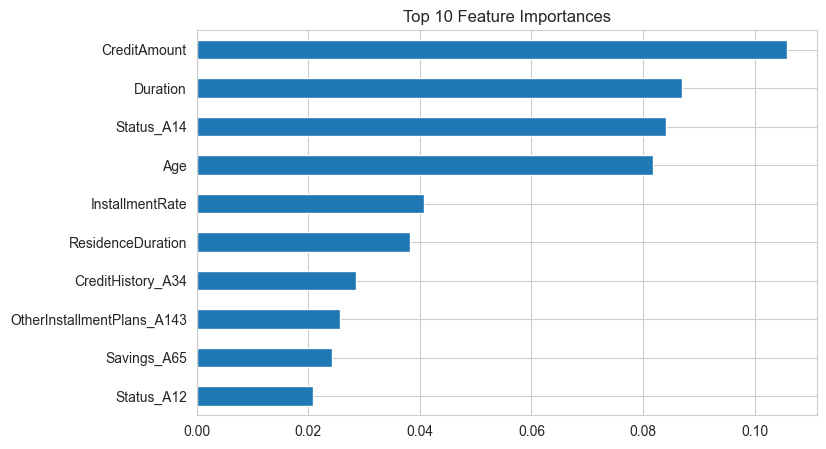

CreditAmount                  0.105793
Duration                      0.086959
Status_A14                    0.084180
Age                           0.081736
InstallmentRate               0.040814
ResidenceDuration             0.038283
CreditHistory_A34             0.028599
OtherInstallmentPlans_A143    0.025694
Savings_A65                   0.024184
Status_A12                    0.020826
dtype: float64

In [11]:
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

top_features

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.74
ROC-AUC: 0.8084571428571429

Confusion Matrix:
[[126  49]
 [ 16  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.79       175
           1       0.55      0.79      0.64        75

    accuracy                           0.74       250
   macro avg       0.72      0.75      0.72       250
weighted avg       0.79      0.74      0.75       250



In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Performance
Accuracy: 0.784
ROC-AUC: 0.8080761904761905

Confusion Matrix:
[[154  21]
 [ 33  42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       175
           1       0.67      0.56      0.61        75

    accuracy                           0.78       250
   macro avg       0.75      0.72      0.73       250
weighted avg       0.78      0.78      0.78       250



In [15]:
rf_auc = roc_auc_score(y_test, y_prob)
lr_auc = roc_auc_score(y_test, lr_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Model Comparison (ROC-AUC)")
print("Random Forest:", rf_auc)
print("Logistic Regression:", lr_auc)
print("XGBoost:", xgb_auc)

auc_scores = {
    "Random Forest": rf_auc,
    "Logistic Regression": lr_auc,
    "XGBoost": xgb_auc
}

best_model_name = max(auc_scores, key=auc_scores.get)

if best_model_name == "Random Forest":
    best_model = model
elif best_model_name == "Logistic Regression":
    best_model = lr_model
else:
    best_model = xgb_model

print("\nBest Model Selected:", best_model_name)

Model Comparison (ROC-AUC)
Random Forest: 0.786247619047619
Logistic Regression: 0.8084571428571429
XGBoost: 0.8080761904761905

Best Model Selected: Logistic Regression
